In [69]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
np.set_printoptions(linewidth=np.inf) #把輸出的寬設成無限大

## 均值濾波

In [70]:
one_matrix = np.ones((3,3))
mean_kernel = one_matrix / one_matrix.size
print(mean_kernel)

[[0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]]


In [71]:
h, w = image.shape
kh, kw = mean_kernel.shape

# 計算 padding 大小 (預計捲積後大小不變)
pad_h = (kh - 1) // 2 #pad_size = (kernel_size - 1)/2
pad_w = (kw - 1) // 2
stride = 1

padded_image = np.zeros((h+2*pad_h, w+2*pad_w))
padded_image[pad_h:pad_h+h, pad_w:pad_w+w] = image

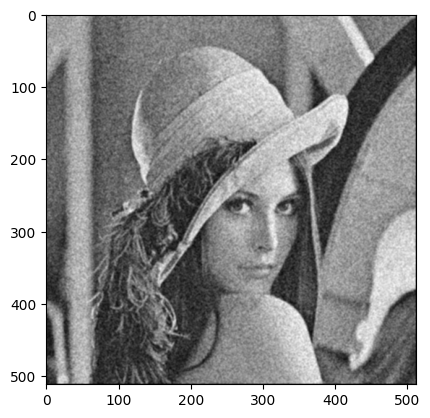

In [49]:
output_h = ((h - kh + 2 * pad_h)//stride) + 1 #New height/width = ((W + 2 ∗ pad − K) / S) + 1
output_w = ((w - kw + 2 * pad_w)//stride) + 1

mean_output = np.zeros((output_h, output_w))
for i in range(output_h):
  for j in range(output_w):
    #根據stride選擇開始點
    strat_i = i*stride
    start_j = j*stride

    roi = padded_image[strat_i:strat_i+kh, start_j:start_j+kw]
    mean_output[i, j] = np.sum(roi * mean_kernel)

print("均值濾波後矩陣：")
print(mean_output)

## 高斯濾波 (二維函數)

$$
G(x, y) = \frac{1}{2\pi\sigma^2} \, e^{-\frac{x^2 + y^2}{2\sigma^2}}
$$


In [50]:
# 產生高斯核
gaussian_size = 3
sigma = 1.0
gaussian_kernel = np.zeros((gaussian_size, gaussian_size))
center = gaussian_size // 2

for i in range(gaussian_size):
    for j in range(gaussian_size):
        x = i - center
        y = j - center
        gaussian_kernel[i, j] = np.exp(-(x**2 + y**2) / (2 * sigma**2))
gaussian_kernel = gaussian_kernel / np.sum(gaussian_kernel)
print(gaussian_kernel)

[[0.07511361 0.1238414  0.07511361]
 [0.1238414  0.20417996 0.1238414 ]
 [0.07511361 0.1238414  0.07511361]]


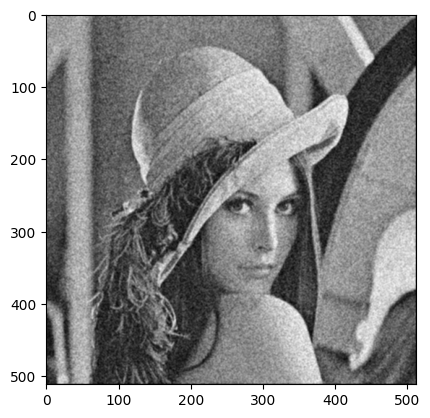

In [52]:
# 填充影像
padded_image2 = np.zeros((h + 2*pad_h, w + 2*pad_w))
padded_image2[pad_h:pad_h+h, pad_w:pad_w+w] = image

# 創建輸出影像
gaussian_output = np.zeros((h, w))

for i in range(h):
  for j in range(w):
    roi = padded_image2[i:i+kh, j:j+kw]
    gaussian_output[i, j] = np.sum(roi * gaussian_kernel)
plt.imshow(gaussian_output,cmap="gray")

## 中值濾波

In [9]:
# 創建有雜訊的影像
noisy_image = image.copy()
noisy_image[2, 2] = 0    # 椒雜訊
noisy_image[3, 3] = 255  # 鹽雜訊
print(noisy_image)

[[ 10.  10.  10.  10.  10.  10.  10.  10.]
 [ 10.  50.  50.  50.  50.  50.  50.  10.]
 [ 10.  50.   0. 100. 100. 100.  50.  10.]
 [ 10.  50. 100. 255. 150. 100.  50.  10.]
 [ 10.  50. 100. 150. 150. 100.  50.  10.]
 [ 10.  50. 100. 100. 100. 100.  50.  10.]
 [ 10.  50.  50.  50.  50.  50.  50.  10.]
 [ 10.  10.  10.  10.  10.  10.  10.  10.]]


In [10]:
median_size = 3
median_pad = (median_size+1) // 2

# 填充影像（使用邊界複製）
padded_image4 = np.zeros((h + 2*median_pad, w + 2*median_pad))
padded_image4[median_pad:median_pad+h, median_pad:median_pad+w] = noisy_image

# 創建輸出影像
median_output = np.zeros((h, w))

# 執行中值濾波
for i in range(h):
    for j in range(w):
        roi = padded_image4[i:i+median_size, j:j+median_size]
        # 取鄰域的中值
        median_output[i, j] = np.median(roi)

print("中值濾波結果:")
print(median_output)

中值濾波結果:
[[  0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   0.  10.  10.  10.  10.  10.  10.]
 [  0.  10.  10.  50.  50.  50.  50.  10.]
 [  0.  10.  50.  50. 100. 100.  50.  50.]
 [  0.  10.  50. 100. 100. 100. 100.  50.]
 [  0.  10.  50. 100. 100. 100. 100.  50.]
 [  0.  10.  50.  50. 100. 100.  50.  50.]
 [  0.  10.  10.  50.  50.  50.  50.  10.]]


## 雙邊濾波

In [38]:
image = cv2.imread("/content/Lenna_noise.png",cv2.IMREAD_GRAYSCALE)
h, w = image.shape
diameter = 9
bil_pad = diameter // 2
sigma_s = 9 #空間域的標準差

padded_image5 = np.zeros((h + 2*bil_pad, w + 2*bil_pad))
padded_image5[bil_pad:bil_pad+h, bil_pad:bil_pad+w] = image

#建立空間權重
ax = np.arange(-bil_pad, bil_pad+1)
xx, yy = np.meshgrid(ax, ax)
spatial_weights = np.exp(-(xx**2 + yy**2) / (2 * sigma_s ** 2))

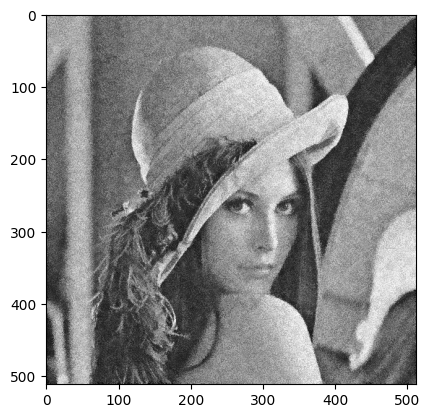

In [39]:
sigma_r = 30 #強度域標準差
bil_filter = np.zeros_like(image, dtype=np.float64)

for i in range(image.shape[0]):
  for j in range(image.shape[1]):
    #取鄰域區塊
    region = padded_image5[i:i+diameter, j:j+diameter]

    #計算亮度差異權重
    intensity_diff = region - image[i, j]
    range_weights = np.exp(-(intensity_diff**2) / (2 * sigma_r**2))

    weights = spatial_weights * range_weights
    Wp = np.sum(weights)

    bil_filter[i, j] = np.sum(region * weights) / Wp

plt.imshow(bil_filter, cmap='gray')

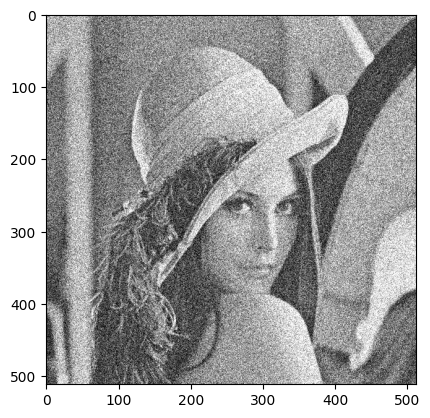

In [66]:
from skimage.util import random_noise

# 生成與影像相同大小的高斯雜訊
gaussian_noise = np.random.normal(20, 25, image.shape)

# 將雜訊加到影像上
noisy_image = image + gaussian_noise

# 限制像素值在 0-255 範圍內
noisy_image = np.clip(noisy_image, 0, 255)
plt.imshow(noisy_image, cmap='gray')

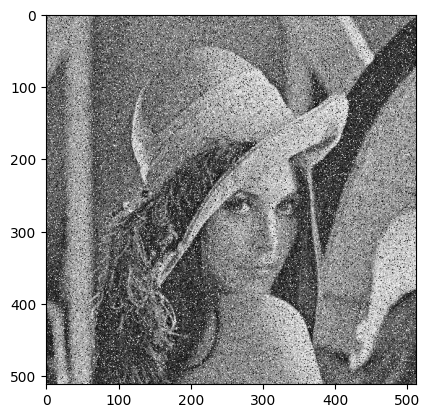

In [68]:
noisy_image = image.copy()
salt_prob = 0.05
pepper_prob = 0.05

# 生成隨機矩陣
random_matrix = np.random.random(image.shape[:2])

# 添加鹽雜訊(白點 = 255)
noisy_image[random_matrix < salt_prob] = 255

# 添加椒雜訊(黑點 = 0)
noisy_image[random_matrix > 1 - pepper_prob] = 0
plt.imshow(noisy_image, cmap='gray')